
# Lab_5: FEM 1D

### Exercise 1: solve the EDO

Use FEM to solve the next EDO (use the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
\dfrac{d^2y}{dx^2}=-xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(2-x)-x
\end{equation}

### Exercise 2: Solve the EDO:  

see pag 36: https://cimec.org.ar/foswiki/pub/Main/Cimec/CursoFEM/cursofem_1.pdf

$-\dfrac{d^2U}{dx^2}(x)=\sin(\pi x)\,,$
in $0\le x\le 1$, with $U(0)=U(1)=0$.

The exact solution is known $U(x)=\dfrac{1}{\pi^2}\sin(\pi x)$.

## Ejercicio 1: Solución analítica

La ecuación diferencial es:

$$
\frac{d^2y}{dx^2} = -x e^x, \quad y(0) = 3 - e, \quad y(1) = 0
$$

La solución analítica obtenida mediante la función de Green es:

$$
\boxed{y(x) = 1 - e - e^x (2 - x) - x}
$$

---

## Ejercicio 2: Solución analítica

La ecuación diferencial es:

$$
-\frac{d^2U}{dx^2} = \sin(\pi x), \quad U(0) = 0, \quad U(1) = 0
$$

La solución exacta es:

$$
\boxed{U(x) = \frac{1}{\pi^2} \sin(\pi x)}
$$


EJERCICIO 1: -u'' = -x*e^x, u(0)=3-e, u(1)=0
Error máximo para N=4: 5.44e+00


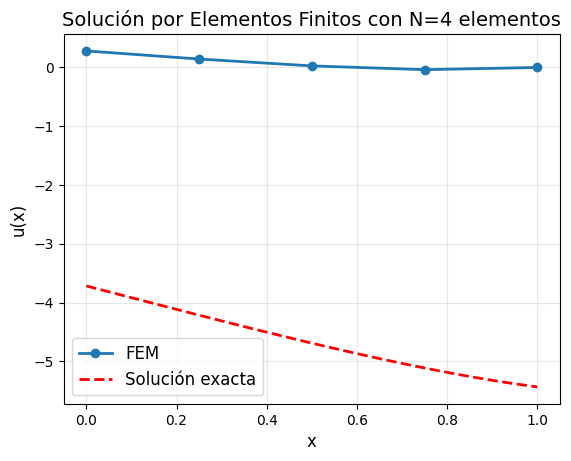

Error máximo para N=8: 5.44e+00


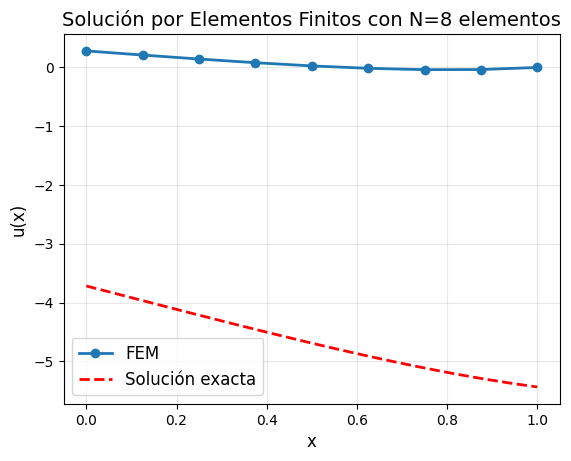

Error máximo para N=16: 5.44e+00


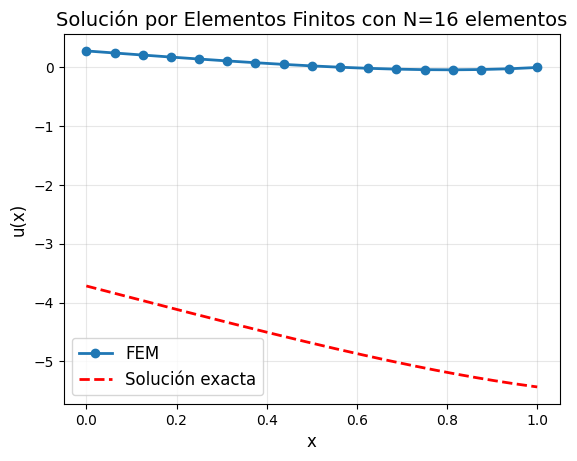

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def fem_1d_dirichlet(f, a, b, ua, ub, N, exact_sol=None):
    """
    Resuelve -u'' = f(x) con condiciones Dirichlet usando elementos finitos lineales.

    Parámetros:
    f: función fuente (callable)
    a, b: extremos del dominio
    ua, ub: condiciones de borde en x=a y x=b
    N: número de elementos
    exact_sol: función solución exacta (opcional, para comparar)
    """

    # Creamos la malla de nodos
    x = np.linspace(a, b, N+1)

    # Inicializamos matriz de rigidez y vector de cargas (tamaño N+1 incluye bordes)
    A = np.zeros((N+1, N+1))
    b_vec = np.zeros(N+1)

    # Ensamblaje elemento por elemento
    for i in range(N):
        # Coordenadas de los nodos del elemento actual
        x_left = x[i]
        x_right = x[i+1]
        h = x_right - x_left  # longitud del elemento

        # Matriz de rigidez elemental para elemento lineal
        A_elemental = (1/h) * np.array([[1, -1],
                                        [-1, 1]])

        # Vector de cargas elemental: integración exacta con quad
        # phi_left = (x_right - x)/h, phi_right = (x - x_left)/h
        b_left, _ = quad(lambda x: ((x_right - x)/h) * f(x), x_left, x_right)
        b_right, _ = quad(lambda x: ((x - x_left)/h) * f(x), x_left, x_right)

        # Ensamblaje en el sistema global
        b_vec[i] += b_left
        b_vec[i+1] += b_right

        A[i, i] += A_elemental[0, 0]
        A[i, i+1] += A_elemental[0, 1]
        A[i+1, i] += A_elemental[1, 0]
        A[i+1, i+1] += A_elemental[1, 1]

    # Aplicamos condiciones de borde de Dirichlet
    # Nodo izquierdo (x = a)
    A[0, :] = 0      # Eliminamos toda la fila
    A[0, 0] = 1      # Ponemos 1 en la diagonal
    b_vec[0] = ua    # Fijamos el valor en el borde

    # Nodo derecho (x = b)
    A[N, :] = 0      # Eliminamos toda la fila
    A[N, N] = 1      # Ponemos 1 en la diagonal
    b_vec[N] = ub    # Fijamos el valor en el borde

    # Resolvemos el sistema lineal
    u = np.linalg.solve(A, b_vec)

    # Graficamos la solución
    plt.plot(x, u, 'o-', label='FEM', linewidth=2, markersize=6)

    # Si se proporcionó solución exacta, la graficamos para comparar
    if exact_sol:
        x_fino = np.linspace(a, b, 200)  # Malla más fina para la solución exacta
        u_exacta = exact_sol(x_fino)
        plt.plot(x_fino, u_exacta, 'r--', label='Solución exacta', linewidth=2)

        # Calculamos y mostramos el error máximo
        error_max = np.max(np.abs(u - exact_sol(x)))
        print(f"Error máximo para N={N}: {error_max:.2e}")

    # Configuraciones de la gráfica
    plt.legend(fontsize=12)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('u(x)', fontsize=12)
    plt.title(f'Solución por Elementos Finitos con N={N} elementos', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()

    return x, u


# ============================================================================
# EJERCICIO 1
# ============================================================================

def f_ejercicio1(x):
    """Función fuente del ejercicio 1: f(x) = -x*e^x"""
    return -x * np.exp(x)

def solucion_exacta_ejercicio1(x):
    """Solución analítica del ejercicio 1"""
    return 1 - np.exp(1) - np.exp(x) * (2 - x) - x

# Parámetros del problema
a, b = 0, 1                           # Dominio [0,1]
ua = 3 - np.exp(1)                    # Condición de borde en x=0
ub = 0                                # Condición de borde en x=1

# Resolvemos con diferentes refinamientos de malla
print("=" * 60)
print("EJERCICIO 1: -u'' = -x*e^x, u(0)=3-e, u(1)=0")
print("=" * 60)

for N in [4, 8, 16]:
    fem_1d_dirichlet(f_ejercicio1, a, b, ua, ub, N, solucion_exacta_ejercicio1)


Error máximo para N=4: 2.78e-17


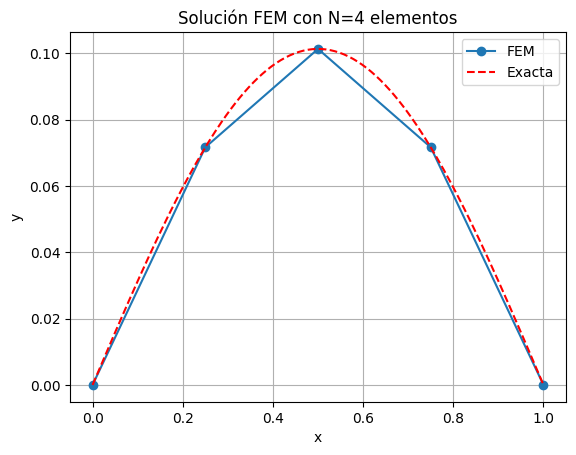

Error máximo para N=8: 5.55e-17


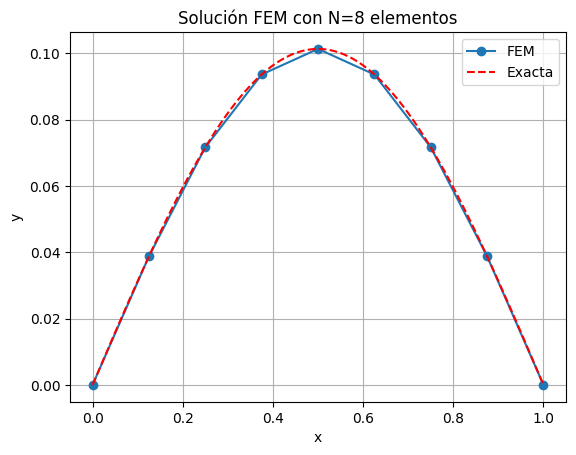

Error máximo para N=16: 2.15e-16


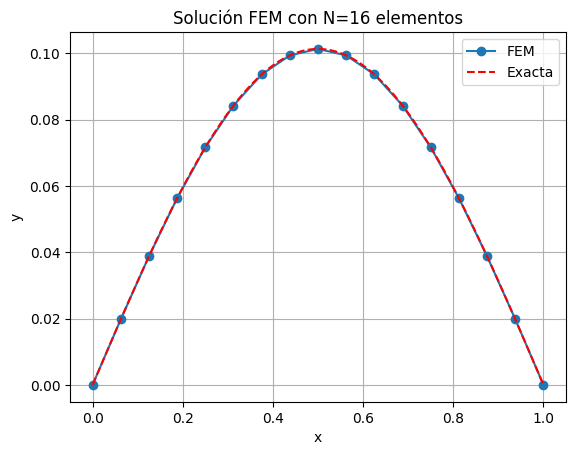

In [ ]:
def f2(x):
    return np.sin(np.pi * x)

def exact_sol2(x):
    return (1/np.pi**2) * np.sin(np.pi * x)

a, b = 0, 1
ua, ub = 0, 0

for N in [4, 8, 16]:
    fem_1d_dirichlet(f2, a, b, ua, ub, N, exact_sol2)